<a href="https://colab.research.google.com/github/mmz197/Big_data_analytics_project/blob/main/bigdatatask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import  pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

print("Path to dataset files:", path)

import os

# The 'path' variable is available from the previous cell's execution.
# List contents of the directory
files_in_directory = os.listdir(path)
print("Files in the dataset directory:", files_in_directory)

# Assuming the CSV file is the only one or has a recognizable name
csv_files = [f for f in files_in_directory if f.endswith('.csv')]

if csv_files:
    # Take the first CSV file found
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    print("Detected CSV file:", full_csv_path)

    dataset = pd.read_csv(full_csv_path)
    dataset.head()
else:
    print("No CSV files found in the directory. Please check the directory contents.")


Using Colab cache for faster access to the 'twitter-tweets-sentiment-dataset' dataset.
Path to dataset files: /kaggle/input/twitter-tweets-sentiment-dataset
Files in the dataset directory: ['Tweets.csv']
Detected CSV file: /kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv


In [ ]:

import os

# The 'path' variable is available from the previous cell's execution.
# List contents of the directory
files_in_directory = os.listdir(path)
print("Files in the dataset directory:", files_in_directory)

# Assuming the CSV file is the only one or has a recognizable name
csv_files = [f for f in files_in_directory if f.endswith('.csv')]

if csv_files:
    # Take the first CSV file found
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    print("Detected CSV file:", full_csv_path)

    dataset = pd.read_csv(full_csv_path)
    dataset.head()
else:
    print("No CSV files found in the directory. Please check the directory contents.")


Files in the dataset directory: ['Tweets.csv']
Detected CSV file: /kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv


In [ ]:
d1=pd.read_csv('/kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv')
d1.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
d1.tail()

,textID,text,selected_text,sentiment
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive
27480,6f7127d9d7,All this flirting going on - The ATG smiles...,All this flirting going on - The ATG smiles. Y...,neutral


In [ ]:
# Install PySpark
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, regexp_replace, explode, split
from collections import Counter
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("SocialMediaSentimentAnalysis") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
# Replace with your uploaded file name
file_path = "/kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)

# Show dataset
df.show(5)

# Print schema
df.printSchema()

+----------+--------------------+--------------------+---------+
|    textID|                text|       selected_text|sentiment|
+----------+--------------------+--------------------+---------+
|cb774db0d1| I`d have respond...|I`d have responde...|  neutral|
|549e992a42| Sooo SAD I will ...|            Sooo SAD| negative|
|088c60f138|my boss is bullyi...|         bullying me| negative|
|9642c003ef| what interview! ...|      leave me alone| negative|
|358bd9e861| Sons of ****, wh...|       Sons of ****,| negative|
+----------+--------------------+--------------------+---------+
only showing top 5 rows
root
 |-- textID: string (nullable = true)
 |-- text: string (nullable = true)
 |-- selected_text: string (nullable = true)
 |-- sentiment: string (nullable = true)



In [ ]:
total_records = df.count()

print("Total Records:", total_records)

Total Records: 27481


In [ ]:
category_count = df.groupBy("sentiment").count()

category_count.show()

+---------+-----+
|sentiment|count|
+---------+-----+
| positive| 8582|
|     NULL|    2|
|  neutral|11118|
| negative| 7779|
+---------+-----+



In [ ]:
positive_posts = df.filter(col("sentiment") == "positive")

print("Positive Posts Count:", positive_posts.count())

positive_posts.show(5)

Positive Posts Count: 8582
+----------+--------------------+--------------------+---------+
|    textID|                text|       selected_text|sentiment|
+----------+--------------------+--------------------+---------+
|6e0c6d75b1|2am feedings for ...|                 fun| positive|
|fc2cbefa9d| Journey!? Wow......|Wow... u just bec...| positive|
|16fab9f95b|I really really l...|                like| positive|
|e48b0b8a23|Playing Ghost Onl...|        interesting.| positive|
|e00c6ef376|the free fillin` ...|the free fillin` ...| positive|
+----------+--------------------+--------------------+---------+
only showing top 5 rows


In [ ]:
negative_posts = df.filter(col("sentiment") == "negative")

print("Negative Posts Count:", negative_posts.count())

negative_posts.show(5)

Negative Posts Count: 7779
+----------+--------------------+--------------+---------+
|    textID|                text| selected_text|sentiment|
+----------+--------------------+--------------+---------+
|549e992a42| Sooo SAD I will ...|      Sooo SAD| negative|
|088c60f138|my boss is bullyi...|   bullying me| negative|
|9642c003ef| what interview! ...|leave me alone| negative|
|358bd9e861| Sons of ****, wh...| Sons of ****,| negative|
|74a76f6e0a|My Sharpie is run...|   DANGERously| negative|
+----------+--------------------+--------------+---------+
only showing top 5 rows


In [ ]:
clean_df = df.withColumn(
    "clean_text",
    lower(
        regexp_replace(col("text"), "[^a-zA-Z\\s]", "")
    )
)

clean_df.select("clean_text").show(5, truncate=False)

+---------------------------------------------------------------------+
|clean_text                                                           |
+---------------------------------------------------------------------+
| id have responded if i were going                                   |
| sooo sad i will miss you here in san diego                          |
|my boss is bullying me                                               |
| what interview leave me alone                                       |
| sons of  why couldnt they put them on the releases we already bought|
+---------------------------------------------------------------------+
only showing top 5 rows


In [ ]:
# Split words
words_df = clean_df.select(
    explode(
        split(col("clean_text"), "\\s+")
    ).alias("word")
)

# Remove empty words
words_df = words_df.filter(col("word") != "")

# Count frequency
word_counts = words_df.groupBy("word").count()

# Sort descending
top_keywords = word_counts.orderBy(col("count").desc())

# Show top 20 keywords
top_keywords.show(20)

+----+-----+
|word|count|
+----+-----+
|   i|13179|
|  to|10015|
| the| 8984|
|   a| 6715|
|  my| 5512|
| and| 5070|
| you| 4813|
|  it| 4061|
|  is| 3973|
|  in| 3784|
| for| 3652|
|  of| 3144|
|  im| 3055|
|  on| 2852|
|  me| 2812|
|have| 2594|
|  so| 2575|
|that| 2568|
| but| 2304|
|just| 2245|
+----+-----+
only showing top 20 rows


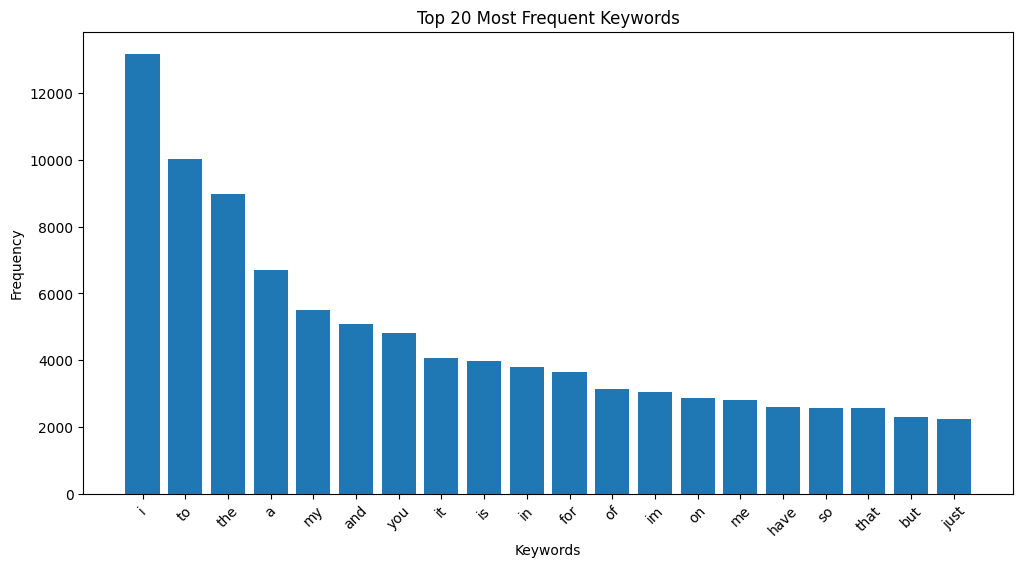

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(top20['word'], top20['count'])

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Keywords")

plt.xlabel("Keywords")

plt.ylabel("Frequency")

plt.show()

In [ ]:
print("========== SUMMARY ==========")

print("Total Posts:", total_records)

print("\nPosts Per Category:")
category_count.show()

print("Positive Posts:", positive_posts.count())

print("Negative Posts:", negative_posts.count())

print("\nTop Keywords:")
top_keywords.show(10)

========== SUMMARY ==========
Total Posts: 27481

Posts Per Category:
+---------+-----+
|sentiment|count|
+---------+-----+
| positive| 8582|
|     NULL|    2|
|  neutral|11118|
| negative| 7779|
+---------+-----+

Positive Posts: 8582
Negative Posts: 7779

Top Keywords:
+----+-----+
|word|count|
+----+-----+
|   i|13179|
|  to|10015|
| the| 8984|
|   a| 6715|
|  my| 5512|
| and| 5070|
| you| 4813|
|  it| 4061|
|  is| 3973|
|  in| 3784|
+----+-----+
only showing top 10 rows


In [ ]:
d1.dtypes

,0
textID,object
text,object
selected_text,object
sentiment,object
